<h3> SciPython/Practical_classes_2

<h3> Bayesian approach

- fast to calculate
- easy to interpret
- easy to implement

Let's assume we have some categories (for example: cats and dogs) and $L$ is the category we want to predict. We want to build a model that will predict the category $L$ based on a set of features $(X_1, X_2, ..., X_n)$. According to Bayes' theorem

<br> <center> $P(L|X_1,X_2,...,X_n) = \frac{P(X_1,X_2,...,X_n|L)P(L)}{P(X_1,X_2,...,X_n)}$ </center> <br>

The probability $P(L|X_1,X_2,...,X_n)$ is called the posterior probability — it describes how likely the category $L$ is given the observed features. The higher this probability is, the more likely we are to classify the observation as belonging to category $L$.

If we have only two categories $L_1$ and $L_2$, we may investigate the ratio

<br> <center> $\frac{P(L_1|X_1,X_2,...,X_n)}{P(L_2|X_1,X_2,...,X_n)}$ </center>

which is

<br> <center> $\frac{P(L_1|X_1,X_2,...,X_n)}{P(L_2|X_1,X_2,...,X_n)} = \frac{P(X_1,X_2,...,X_n|L_1)P(L_1)}{P(X_1,X_2,...,X_n|L_2)P(L_2)}$ </center>

Note that the term $P(X_1,X_2,...,X_n)$ cancels out in the ratio, since it is the same for both categories.

Based on the training data, we approximate the probabilities $P(X_1,X_2,...,X_n|L_i)$ and $P(L_i)$. To do this, we typically assume a specific distribution for the data (for example, a normal distribution).

As a result, we obtain a generative model: a model that describes how the data $(X_1, X_2, ..., X_n)$ are generated for each category $L_i$. Because the model specifies the joint distribution of features and labels, it can also be used to generate new synthetic data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(1000, 2, centers = 2, random_state = 1, cluster_std = 3) #data and labels (categories), method for generating artificial data

print(X[:10]); print(); print(y[:10])

[[ -5.85599836   4.65179333]
 [ -5.83379108  -3.27474928]
 [  7.43301143   6.88024374]
 [ -8.02210189  -0.9566436 ]
 [-14.71993278  -3.65156829]
 [-14.27229521  -6.66367673]
 [-11.34013232  -3.38759981]
 [-11.34268182  -1.87528181]
 [  1.46070755   1.65116975]
 [-12.73804273  -5.82506401]]

[0 1 0 1 1 1 1 1 0 1]


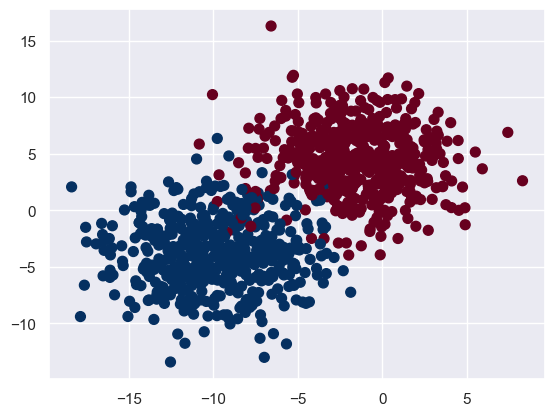

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="RdBu")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) #divide the data into the training and test sets

<h4>Normal distribution

In [5]:
from sklearn.naive_bayes import GaussianNB #we asuume P(X1,...,Xn |L) is normal 

model = GaussianNB() #create a model
model.fit(X_train, y_train); #fit a model to training data

In [6]:
#check how the model works
y_predicted = model.predict(X_test)
sum([1 for i in range(len(y_test)) if y_test[i] == y_predicted[i]])/len(y_test) #accuracy on the test set

0.975

In [7]:
#in-built method
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predicted) #check how the model works

0.975

In [8]:
#for a given data observation we may predict the probability of every category
model.predict_proba([[-5,-1]])

array([[0.33548546, 0.66451454]])

### Exercise 1


Consider the Iris dataset. Divide the data into a training set and a test set using a 9:1 split. Train a model using the Naive Bayes approach and evaluate it on the test set. What accuracy does the model achieve?

data description: https://archive.ics.uci.edu/ml/datasets/Iris/

In [9]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target

print(X[:10]); print(); print(y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<h3> Multinomial distribution

In [10]:
from sklearn.naive_bayes import MultinomialNB # appropriate for features that desribe counts of sth

In [11]:
from sklearn.datasets import fetch_20newsgroups #contain over 18K posts regarding on 20 topics

data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [12]:
categories = ["sci.med", "sci.space", "comp.windows.x"] #choose 3 categories
train = fetch_20newsgroups(subset = "train", categories = categories)
test = fetch_20newsgroups(subset = "test", categories = categories)

In [13]:
print(len(train.data), len(test.data))

1780 1185


In [14]:
train.target_names #categories

['comp.windows.x', 'sci.med', 'sci.space']

In [15]:
print(train.data[0])

From: jra@wti.com (Jim Atkinson)
Subject: How can I detect local vs remote DISPLAY settings?
Reply-To: jra@wti.com
Organization: Wavefront Technologies Inc, Santa Barbara, CA
Lines: 17
Nntp-Posting-Host: barracuda.wti.com
X-Disclaimer: Not a spokesperson for Wavefront Technologies, Inc.

I am trying to find out if my application is running on a local or a
remote display.  A local display being connected to the same system
that the client is executing on.  I have access to the display string
but can I tell from the string?

If the client is executing on host foo then ":0", "unix:0", "foo:0",
and "localhost:0" are all local.  Under Ultrix, I believe that
"local:0" is also a valid display name (a shared memory connection
maybe?).  Are there other strings that I should check for?  Is there a
better way to detect this?

Thank you for any help you can give me.
-- 
Jim Atkinson		Wavefront Technologies, Inc.
jra@wti.com		What, me?  A company spokesperson?  Get real!
=================== Life is

In [16]:
#to analyse the text we need to convert it into numbers
from sklearn.feature_extraction.text import TfidfVectorizer #method TF-IDF is a technique to convert the text into numbers

In [1]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(TfidfVectorizer(), MultinomialNB()) #we make a pipeline, 1. Text->numbers, 2. NB model
model

In [18]:
model.fit(train.data, train.target)
categories_predicted = model.predict(test.data)

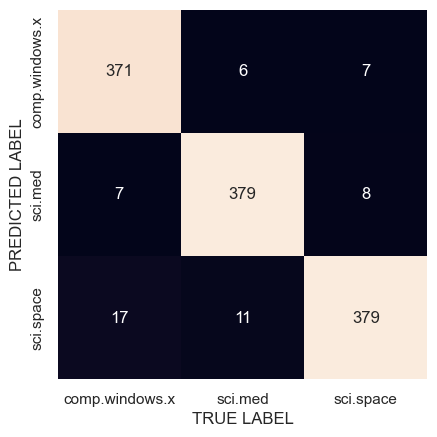

In [19]:
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(test.target, categories_predicted)

sns.heatmap(mat.T, square=True, annot=True, fmt="d", cbar=False, 
            xticklabels = train.target_names, yticklabels=train.target_names)

plt.xlabel("TRUE LABEL")
plt.ylabel("PREDICTED LABEL")
plt.show()

In [20]:
#if we want to predic a new sentence
s = "black hole is a misterious object"
model.predict([s])

array([2], dtype=int64)

<h3> Bayesian networks

<h4> Assumptions </h4>

- take the form of a directed (edges are directed in one direction), acyclic (no cycles) graph (DAG=directd acyclic graph)
- convenient for modeling cause-and-effect relationships

There are
- verticles (variables, features)
- edges (dependencies between features)

Syntax: If $A \rightarrow B$, then we call $A$ a parent of $B$ and $B$ is the child of $A$.

Each variable (represented by a vertex) is conditionally dependent of the parents variables.


$P(X_1=x_1,X_2=x_2,....) = \prod_i P(X_i=x_i|parents(X_i))$



<h4> Example (from Judea Pearl)</h4>

- The owner of the house works far away from his home.
- An alarm has been installed to prevent burglary. Unfortunately, earthquakes can also trigger alarms.
- Neighbors - John and Mary call the homeowner when they hear an alarm (with some probability).

Below is a diagram of this situation:

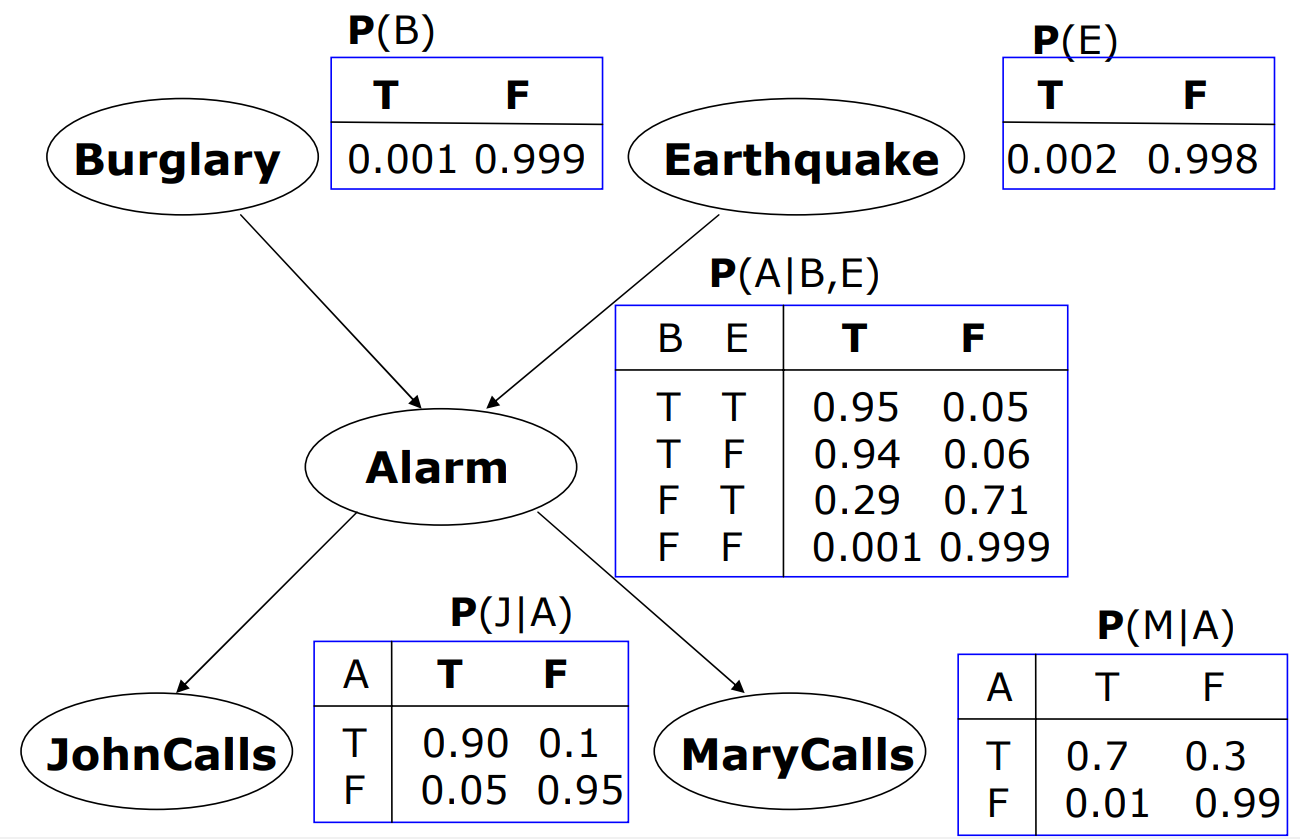

In [21]:
from IPython import display
display.Image("nb.png", width="500", height="500")

### Exercise 2

Calculate $P(B=T, E=T, A=T, J=T, M=F)$.

### Exercise 3 (the reduction in the number of parameters):

- How many parameters are needed to describe the joint distribution of 5 binary variables?
- How many parameters does the above network have?

### Exercise4: 
Answer the same questions as previously, but this time for 10 binary variables network and the following topology:

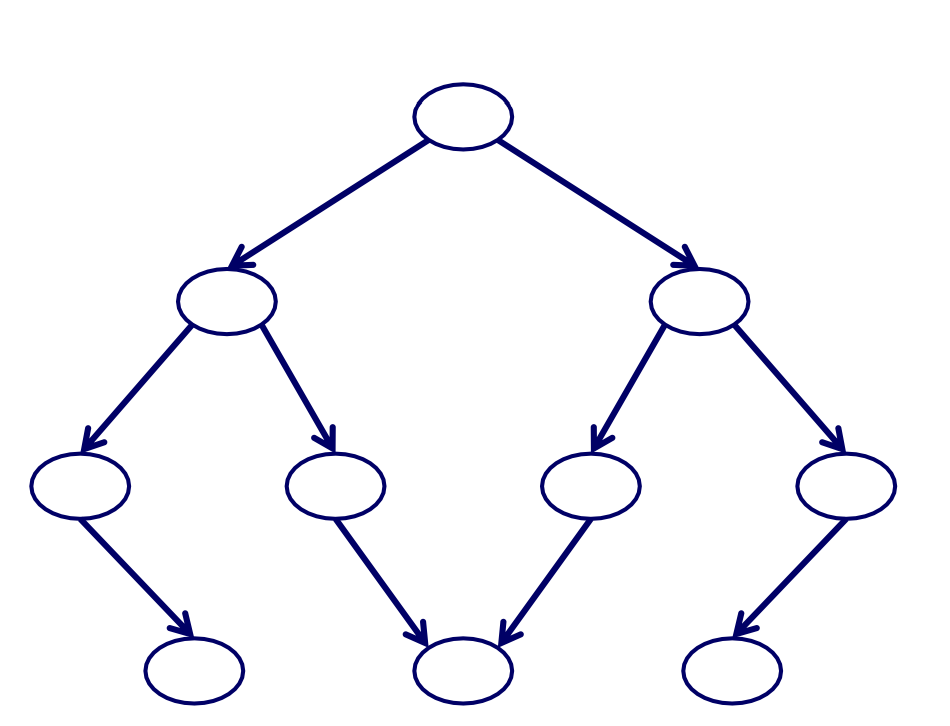

In [22]:
display.Image("nb2.png", width="500", height="500")

And now, some examples in Python

https://pgmpy.org/started/base.html

In [21]:
import pandas as pd

In [22]:
import pandas as pd
data = pd.read_csv('bn_data.csv')
print(data)

     fruit tasty   size
0   banana   yes  large
1    apple    no  large
2   banana   yes  large
3    apple   yes  small
4   banana   yes  large
5    apple   yes  large
6   banana   yes  large
7    apple   yes  small
8    apple   yes  large
9    apple   yes  large
10  banana   yes  large
11  banana    no  large
12   apple    no  small
13  banana    no  small


In [2]:
from pgmpy.models import DiscreteBayesianNetwork #need to install (pip install pgmpy), https://pgmpy.org/started/install.html

nb_net = DiscreteBayesianNetwork([('fruit', 'tasty'), ('size', 'tasty')])  #we create a bayesian network with relations: fruit -> tasty and size->tasty

In [24]:
nb_net.edges()

OutEdgeView([('fruit', 'tasty'), ('size', 'tasty')])

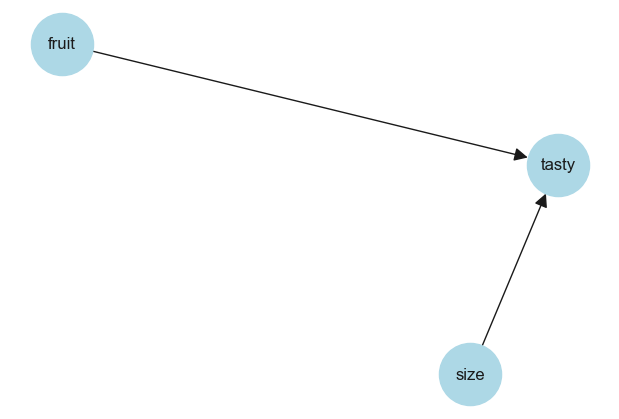

In [25]:
#network plotting

import networkx as nx

G = nx.DiGraph(nb_net.edges())
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_size=2000, node_color='lightblue', arrowsize=20)
plt.show()

In [26]:
#some calculations
from pgmpy.estimators import ParameterEstimator
p = ParameterEstimator(nb_net, data)

print(p.state_counts('fruit'))
print()
print(p.state_counts('size'))
print()
print(p.state_counts('tasty'))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


        count
fruit        
apple       7
banana      7

       count
size        
large     10
small      4

fruit apple       banana      
size  large small  large small
tasty                         
no      1.0   1.0    1.0   1.0
yes     3.0   2.0    5.0   0.0


In [27]:
from pgmpy.estimators import MaximumLikelihoodEstimator

mle_model = MaximumLikelihoodEstimator(nb_net, data) #probability estimation based on MLE
print(mle_model.estimate_cpd('fruit'))  
print(mle_model.estimate_cpd('size')) 
print(mle_model.estimate_cpd('tasty'))  

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


+---------------+-----+
| fruit(apple)  | 0.5 |
+---------------+-----+
| fruit(banana) | 0.5 |
+---------------+-----+
+-------------+----------+
| size(large) | 0.714286 |
+-------------+----------+
| size(small) | 0.285714 |
+-------------+----------+
+------------+--------------+--------------------+---------------------+---------------+
| fruit      | fruit(apple) | fruit(apple)       | fruit(banana)       | fruit(banana) |
+------------+--------------+--------------------+---------------------+---------------+
| size       | size(large)  | size(small)        | size(large)         | size(small)   |
+------------+--------------+--------------------+---------------------+---------------+
| tasty(no)  | 0.25         | 0.3333333333333333 | 0.16666666666666666 | 1.0           |
+------------+--------------+--------------------+---------------------+---------------+
| tasty(yes) | 0.75         | 0.6666666666666666 | 0.8333333333333334  | 0.0           |
+------------+--------------+----

In [28]:
from pgmpy.estimators import BayesianEstimator

est = BayesianEstimator(nb_net, data)
print(est.estimate_cpd('tasty', prior_type='K2')) #adding pseudocounts (1) to eliminate zero values

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


+------------+--------------------+--------------+---------------+--------------------+
| fruit      | fruit(apple)       | fruit(apple) | fruit(banana) | fruit(banana)      |
+------------+--------------------+--------------+---------------+--------------------+
| size       | size(large)        | size(small)  | size(large)   | size(small)        |
+------------+--------------------+--------------+---------------+--------------------+
| tasty(no)  | 0.3333333333333333 | 0.4          | 0.25          | 0.6666666666666666 |
+------------+--------------------+--------------+---------------+--------------------+
| tasty(yes) | 0.6666666666666666 | 0.6          | 0.75          | 0.3333333333333333 |
+------------+--------------------+--------------+---------------+--------------------+


### Exercise5

Explain the value of 0.75 in the table above (by direct calculations and explanation).

- Another approach

In [29]:
from pgmpy.estimators import BayesianEstimator

est = BayesianEstimator(nb_net, data)
print(est.estimate_cpd('tasty', prior_type='BDeu', equivalent_sample_size=10)) #another method; BDeu = Bayesian Dirichlet equivalent uniform prior

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fruit': 'C', 'tasty': 'C', 'size': 'C'}


+------------+---------------------+--------------------+--------------------+---------------------+
| fruit      | fruit(apple)        | fruit(apple)       | fruit(banana)      | fruit(banana)       |
+------------+---------------------+--------------------+--------------------+---------------------+
| size       | size(large)         | size(small)        | size(large)        | size(small)         |
+------------+---------------------+--------------------+--------------------+---------------------+
| tasty(no)  | 0.34615384615384615 | 0.4090909090909091 | 0.2647058823529412 | 0.6428571428571429  |
+------------+---------------------+--------------------+--------------------+---------------------+
| tasty(yes) | 0.6538461538461539  | 0.5909090909090909 | 0.7352941176470589 | 0.35714285714285715 |
+------------+---------------------+--------------------+--------------------+---------------------+


prior_type='BDeu' stands for Bayesian Dirichlet equivalent uniform prior. It means that the parameters of the conditional probability distribution are estimated using a Dirichlet prior with a uniform assumption over all possible configurations of the variables.

Instead of relying only on the observed frequencies in the data, the method adds pseudo-counts determined by the parameter equivalent_sample_size. This can be interpreted as the number of virtual observations added to the dataset.

As a result, the estimated probabilities are smoothed and extreme values (such as probabilities equal to 0 or 1 due to small sample sizes) are avoided.

If a variable has $r$ states and its parents have $q$ configurations, then each cell of the CPD receives a pseudo-count of:

<p>$$\frac{equivalent\ sample\ size}{rq}$$</p>

<h4> Example

In [30]:
data = pd.DataFrame(np.random.randint(low=0, high=2, size=(5000, 4)), columns=['A', 'B', 'C', 'D'])

model = DiscreteBayesianNetwork([('A', 'B'), ('A', 'C'), ('D', 'C'), ('B', 'D')])

model.fit(data, estimator=BayesianEstimator, prior_type="BDeu") #by default equivalent_sample_size=5
for cpd in model.get_cpds():
    print(cpd)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N'}


+------+----------+
| A(0) | 0.508591 |
+------+----------+
| A(1) | 0.491409 |
+------+----------+
+------+--------------------+--------------------+
| A    | A(0)               | A(1)               |
+------+--------------------+--------------------+
| B(0) | 0.4935179728933412 | 0.5010164667615369 |
+------+--------------------+--------------------+
| B(1) | 0.5064820271066588 | 0.4989835332384631 |
+------+--------------------+--------------------+
+------+--------------------+-------------------+---------------------+---------------------+
| A    | A(0)               | A(0)              | A(1)                | A(1)                |
+------+--------------------+-------------------+---------------------+---------------------+
| D    | D(0)               | D(1)              | D(0)                | D(1)                |
+------+--------------------+-------------------+---------------------+---------------------+
| C(0) | 0.5023976023976024 | 0.508112806644775 | 0.49560087982403517 | 0

Model evaluation

In [33]:
from pgmpy.estimators import BDeu
from pgmpy.estimators import K2
from pgmpy.estimators import BIC

bdeu = BDeu(data)
k2 = K2(data)
bic = BIC(data)

print(bdeu.score(model))
print(k2.score(model))
print(bic.score(model))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N', 'D': 'N'}


-13890.292886962603
-13893.843455405433
-13900.03101066351


For each parameter, the higher the better

<h4> Network topology searching - hard (NP problem)

1) Brute Force (ExhaustiveSearch)

2) Greedy algorithm (HillClimbSearch)

3) Locate independent variables (e.g. chi2 test) - this will limit the number of possibilities (ConstraintBasedEstimator)

4) MMHC algorithm - a combination of 2 and 3 and a few more nuances

<h4> Example

In [54]:
data = pd.DataFrame(np.random.randint(-2, 2, size=(10000, 2)), columns=list('AB'))
data['C'] = 2*data['A'] + 3*data['B']

data.head()

,A,B,C
0,1,-2,-4
1,-2,0,-4
2,-2,-1,-7
3,0,-1,-3
4,0,-2,-6


In [55]:
from pgmpy.estimators import ExhaustiveSearch
bic = BIC(data)
es = ExhaustiveSearch(data, scoring_method=bic)
best_model = es.estimate()
print("The network with the highest BIC")
print(best_model.edges())

print()
print("BIC/Network")
for score, dag in reversed(es.all_scores()):
    print(score, dag.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}


The network with the highest BIC
[('A', 'C'), ('B', 'C')]

BIC/Network
-28708.041559016772 [('A', 'C'), ('B', 'C')]
-28746.803261071796 [('B', 'C'), ('B', 'A'), ('C', 'A')]
-28746.8032610718 [('A', 'C'), ('B', 'C'), ('B', 'A')]
-28746.8032610718 [('A', 'B'), ('A', 'C'), ('C', 'B')]
-28746.8032610718 [('A', 'B'), ('A', 'C'), ('B', 'C')]
-28746.803261071804 [('B', 'A'), ('C', 'A'), ('C', 'B')]
-28746.803261071804 [('A', 'B'), ('C', 'A'), ('C', 'B')]
-29926.552724976995 [('B', 'C'), ('C', 'A')]
-29926.552724976995 [('A', 'C'), ('C', 'B')]
-29926.552724977002 [('C', 'A'), ('C', 'B')]
-40667.595512191096 [('A', 'B'), ('C', 'B')]
-40669.34105998137 [('B', 'A'), ('C', 'A')]
-41847.34497609628 [('B', 'C')]
-41847.3449760963 [('C', 'B')]
-41849.09052388656 [('A', 'C')]
-41849.09052388657 [('C', 'A')]
-41886.106678151315 [('B', 'C'), ('B', 'A')]
-41886.106678151315 [('A', 'B'), ('B', 'C')]
-41886.10667815132 [('B', 'A'), ('C', 'B')]
-41887.85222594159 [('A', 'C'), ('B', 'A')]
-41887.85222594159 

In [56]:
from pgmpy.estimators import HillClimbSearch

hc = HillClimbSearch(data)
best_model = hc.estimate(scoring_method = bic)
print(best_model.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'N', 'B': 'N', 'C': 'N'}
  0%|                                                                           | 2/1000000 [00:00<2:12:16, 125.99it/s]

[('A', 'C'), ('B', 'C')]


### Exercise6

Load the **`sachs.csv`** dataset, which contains continuous measurements of protein and phospho-protein levels in single human cells under different experimental conditions. Each row represents one observation, and the columns correspond to protein activity levels (e.g., Raf, Mek, Erk, Plcg, PIP2, PIP3, PKC, PKA, Akt, P38, Jnk).

Perform the following steps using **pgmpy**:

1. **Data preprocessing**
   - Since the variables are continuous, discretize each column into **three bins (three categories)** using an appropriate method (e.g., quantile / equal-frequency discretization).

2. **Structure learning**
   - Using the discretized dataset, **learn a Bayesian Network structure**.
   - Apply at least one structure learning algorithm (e.g., **Hill Climb Search**).

3. **Model evaluation**
   - Evaluate the learned network using different scoring metrics:
     - `BDeuScore`
     - `K2Score`
     - `BicScore`
   - Optionally compare networks obtained using different scoring methods.

4. **Visualization**
   - Visualize the resulting Bayesian Network using a graph visualization library (e.g., **networkx + matplotlib**).
   - Make sure nodes and directed edges are clearly labeled.

5. **Interpretation**
   - Briefly describe the relationships between proteins suggested by the learned network.

In [57]:
import pandas as pd

url = "https://huggingface.co/datasets/Causal-Copilot/Causal-Copilot-Dataset/resolve/main/realworld_data/sachs.csv"
data = pd.read_csv(url)
print(data.shape)  # liczba wierszy i kolumn
print(data.head()) # podgląd pierwszych wierszy

(853, 11)
    Raf   Mek   Plcg   PIP2   PIP3    Erk   Akt    PKA    PKC   P38   Jnk
0  26.4  13.2   8.82  18.30  58.80   6.61  17.0  414.0  17.00  44.9  40.0
1  35.9  16.5  12.30  16.80   8.13  18.60  32.5  352.0   3.37  16.5  61.5
2  59.4  44.1  14.60  10.20  13.00  14.90  32.5  403.0  11.40  31.9  19.5
3  73.0  82.8  23.10  13.50   1.29   5.83  11.8  528.0  13.70  28.6  23.1
4  33.7  19.8   5.19   9.73  24.80  21.10  46.1  305.0   4.66  25.7  81.3


### Exercise7
    
The number of possible network topologies for $n$ features is expressed by the following recursive formula
   

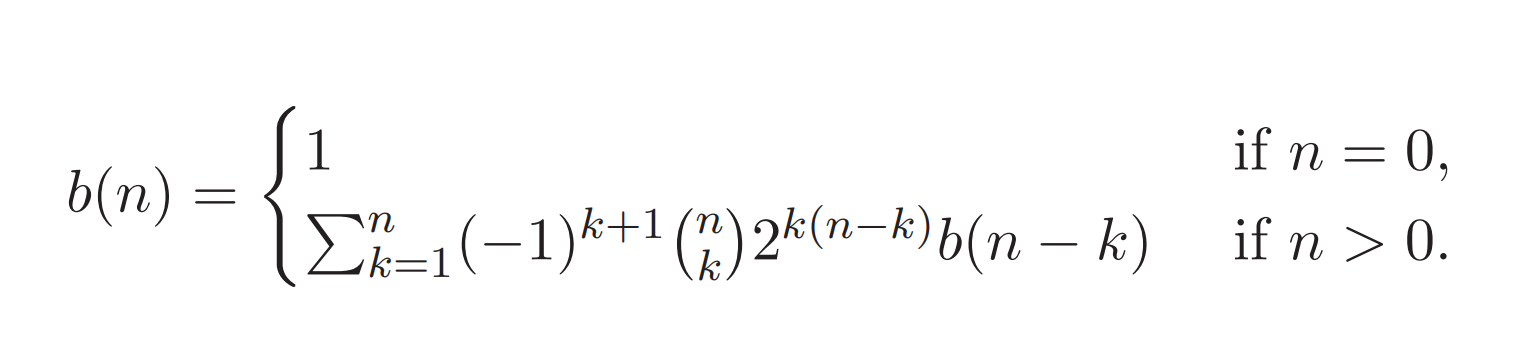

In [34]:
display.Image("bay.png", width="500", height="500")

Implement this formula and check it for 3 features. How many possible networks are in the case of 10 features?


Bayesian networks were developed on the basis of:
- https://pgmpy.org/started/base.html
- https://notebook.community/pgmpy/pgmpy_notebook/notebooks/9.%20Learning%20Bayesian%20Networks%20from%20Data

Worth reading:

- https://www.frontiersin.org/articles/10.3389/fgene.2019.01196/full
- https://biodatamining.biomedcentral.com/articles/10.1186/1756-0381-6-6
- https://www.nature.com/articles/s42003-022-03243-w